In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load the main dataset
df = pd.read_csv('../data/raw/application_train.csv')

print(f"Shape: {df.shape}")
print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nTarget distribution:")
print(df['TARGET'].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean()*100:.2f}%")

Shape: (307511, 122)

Rows: 307,511
Columns: 122

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


In [3]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['missing_count'] > 0]

print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}")
print(f"\nTop 20 columns with most missing data:")
print(missing_df.head(20))

Columns with missing values: 67 out of 122

Top 20 columns with most missing data:
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865       69.872
COMMONAREA_AVG                   214865       69.872
COMMONAREA_MODE                  214865       69.872
NONLIVINGAPARTMENTS_MODE         213514       69.433
NONLIVINGAPARTMENTS_AVG          213514       69.433
NONLIVINGAPARTMENTS_MEDI         213514       69.433
FONDKAPREMONT_MODE               210295       68.386
LIVINGAPARTMENTS_MODE            210199       68.355
LIVINGAPARTMENTS_AVG             210199       68.355
LIVINGAPARTMENTS_MEDI            210199       68.355
FLOORSMIN_AVG                    208642       67.849
FLOORSMIN_MODE                   208642       67.849
FLOORSMIN_MEDI                   208642       67.849
YEARS_BUILD_MEDI                 204488       66.498
YEARS_BUILD_MODE                 204488       66.498
YEARS_BUILD_AVG                  204488       66.498
OWN_CAR_AGE     

In [4]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

print(f"\nCategorical columns:")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} unique values → {df[col].unique()[:5]}")

Numerical columns: 106
Categorical columns: 16

Categorical columns:


/var/folders/fk/wfv7dsk92f3bv6frd75w3gnw0000gn/T/ipykernel_34199/941704867.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


  NAME_CONTRACT_TYPE: 2 unique values → <StringArray>
['Cash loans', 'Revolving loans']
Length: 2, dtype: str
  CODE_GENDER: 3 unique values → <StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str
  FLAG_OWN_CAR: 2 unique values → <StringArray>
['N', 'Y']
Length: 2, dtype: str
  FLAG_OWN_REALTY: 2 unique values → <StringArray>
['Y', 'N']
Length: 2, dtype: str
  NAME_TYPE_SUITE: 7 unique values → <StringArray>
['Unaccompanied', 'Family', 'Spouse, partner', 'Children', 'Other_A']
Length: 5, dtype: str
  NAME_INCOME_TYPE: 8 unique values → <StringArray>
['Working', 'State servant', 'Commercial associate', 'Pensioner',
 'Unemployed']
Length: 5, dtype: str
  NAME_EDUCATION_TYPE: 5 unique values → <StringArray>
['Secondary / secondary special',              'Higher education',
             'Incomplete higher',               'Lower secondary',
               'Academic degree']
Length: 5, dtype: str
  NAME_FAMILY_STATUS: 6 unique values → <StringArray>
['Single / not married', 'Married', 'Civi

In [5]:
# Key numerical columns vs TARGET
key_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

print("Key numerical columns — mean by TARGET:\n")
print(df.groupby('TARGET')[key_cols].mean().T.to_string())

Key numerical columns — mean by TARGET:

TARGET                    0          1
AMT_INCOME_TOTAL 169077.722 165611.761
AMT_CREDIT       602648.282 557778.528
AMT_ANNUITY       27163.623  26481.744
DAYS_BIRTH       -16138.176 -14884.828
DAYS_EMPLOYED     65696.146  42394.675
EXT_SOURCE_1          0.511      0.387
EXT_SOURCE_2          0.523      0.411
EXT_SOURCE_3          0.521      0.391


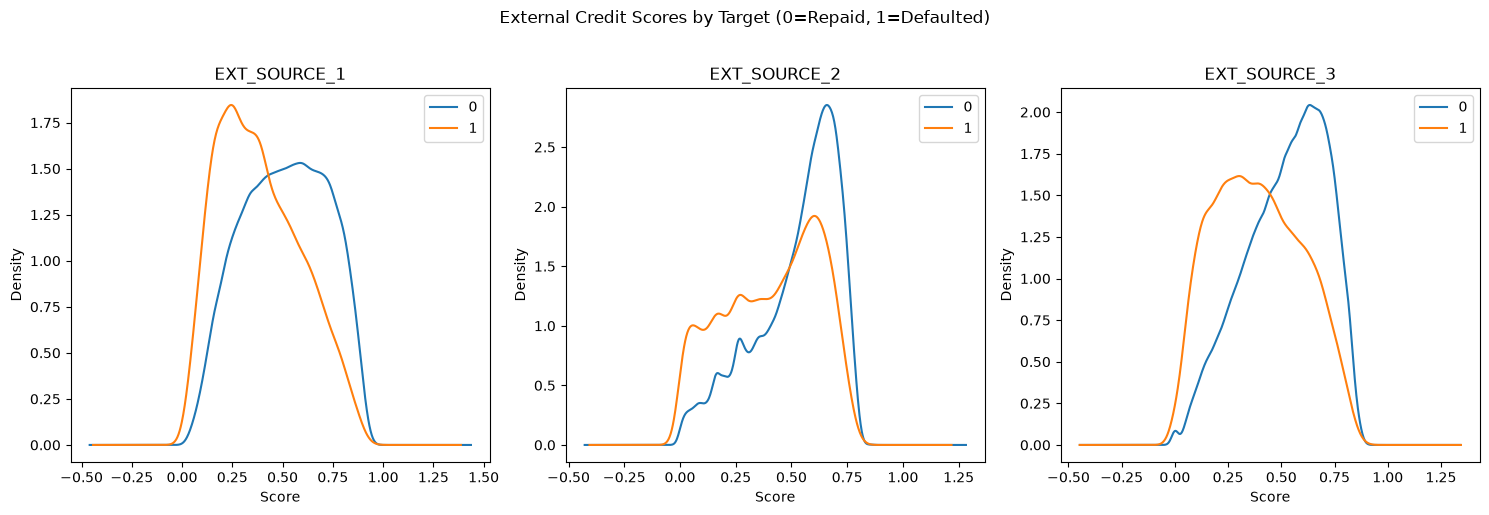

Plot saved


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    df.groupby('TARGET')[col].plot.kde(
        ax=axes[i],
        legend=True,
        title=col
    )
    axes[i].set_xlabel('Score')

plt.suptitle('External Credit Scores by Target (0=Repaid, 1=Defaulted)', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/ext_source_distribution.png', bbox_inches='tight')
plt.show()
print("Plot saved")

/var/folders/fk/wfv7dsk92f3bv6frd75w3gnw0000gn/T/ipykernel_34199/2477936708.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365


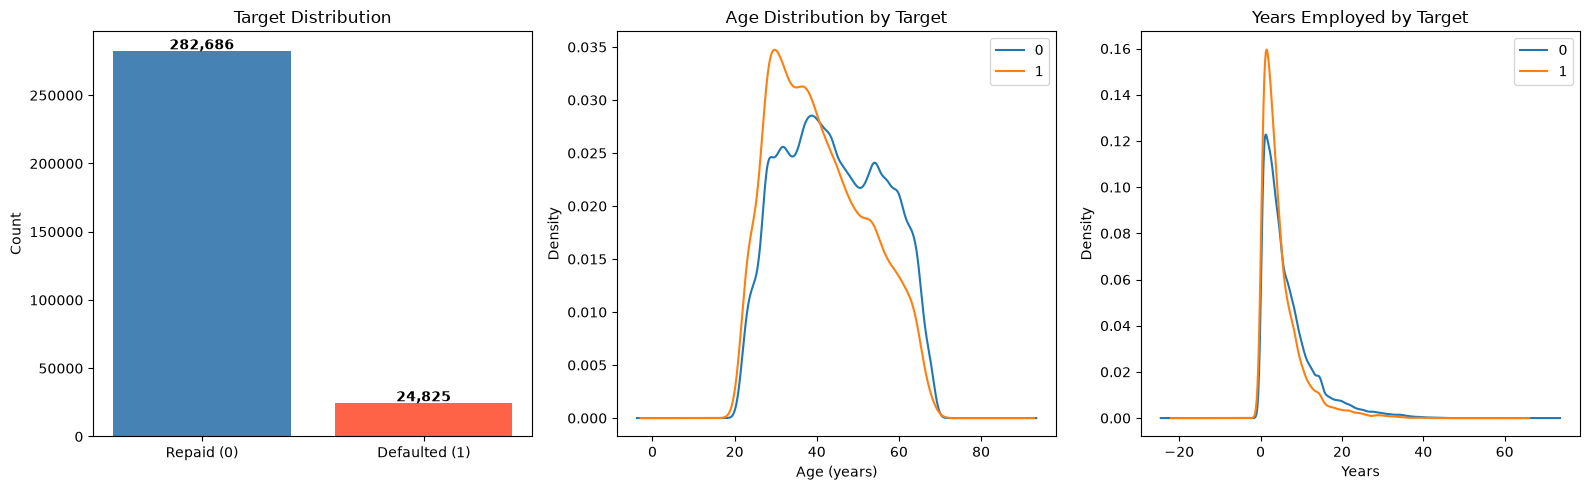

Plot saved


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Target distribution
axes[0].bar(['Repaid (0)', 'Defaulted (1)'],
            df['TARGET'].value_counts().values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['TARGET'].value_counts().values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Age distribution (convert days to years)
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365
df.groupby('TARGET')['AGE_YEARS'].plot.kde(ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Target')
axes[1].set_xlabel('Age (years)')

# Employment length (remove anomaly — positive DAYS_EMPLOYED is an error)
emp = df[df['DAYS_EMPLOYED'] < 0].copy()
emp['YEARS_EMPLOYED'] = abs(emp['DAYS_EMPLOYED']) / 365
emp.groupby('TARGET')['YEARS_EMPLOYED'].plot.kde(ax=axes[2], legend=True)
axes[2].set_title('Years Employed by Target')
axes[2].set_xlabel('Years')

plt.tight_layout()
plt.savefig('../notebooks/target_age_employment.png', bbox_inches='tight')
plt.show()
print("Plot saved")

In [8]:
def process_application_train(df):
    processed = df.copy()

    # 1. Fix DAYS_EMPLOYED anomaly
    processed['DAYS_EMPLOYED'] = processed['DAYS_EMPLOYED'].replace(365243, np.nan)

    # 2. Fix CODE_GENDER anomaly
    processed['CODE_GENDER'] = processed['CODE_GENDER'].replace('XNA', np.nan)

    # 3. Convert days to years (more interpretable)
    processed['AGE_YEARS'] = abs(processed['DAYS_BIRTH']) / 365
    processed['YEARS_EMPLOYED'] = abs(processed['DAYS_EMPLOYED']) / 365

    # 4. Drop columns with more than 50% missing
    missing_pct = processed.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > 0.5].index.tolist()
    # Keep TARGET and SK_ID_CURR no matter what
    cols_to_drop = [c for c in cols_to_drop if c not in ['TARGET', 'SK_ID_CURR']]
    processed = processed.drop(columns=cols_to_drop)
    print(f"Dropped {len(cols_to_drop)} columns with >50% missing")

    # 5. Fill remaining numerical missing values with median
    num_cols = processed.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if processed[col].isnull().any():
            processed[col] = processed[col].fillna(processed[col].median())

    # 6. Fill remaining categorical missing values with mode
    cat_cols = processed.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if processed[col].isnull().any():
            processed[col] = processed[col].fillna(processed[col].mode()[0])

    # 7. One-hot encode categorical columns
    processed = pd.get_dummies(processed, columns=cat_cols.tolist(), drop_first=True)

    print(f"Final shape: {processed.shape}")
    print(f"Missing values remaining: {processed.isnull().sum().sum()}")
    return processed


processed_df = process_application_train(df)

Dropped 41 columns with >50% missing


/var/folders/fk/wfv7dsk92f3bv6frd75w3gnw0000gn/T/ipykernel_34199/230330079.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = processed.select_dtypes(include=['object']).columns


Final shape: (307511, 182)
Missing values remaining: 0


In [9]:
# Save processed data
output_path = '../data/processed/application_train_processed.csv'
processed_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print(f"File size: {processed_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Saved to ../data/processed/application_train_processed.csv
File size: 197.1 MB


In [10]:
print("=== EDA Summary ===")
print(f"Original shape:        (307511, 122)")
print(f"Processed shape:       {processed_df.shape}")
print(f"Columns dropped:       41 (>50% missing)")
print(f"Missing values:        0")
print(f"Target balance:        {(processed_df['TARGET']==0).sum():,} repaid / {(processed_df['TARGET']==1).sum():,} defaulted")
print(f"Default rate:          8.07%")
print(f"\nKey features identified:")
print(f"  - EXT_SOURCE_1/2/3  (strongest predictors)")
print(f"  - AGE_YEARS         (younger = higher risk)")
print(f"  - YEARS_EMPLOYED    (longer employment = lower risk)")
print(f"\nIssues fixed:")
print(f"  - DAYS_EMPLOYED anomaly (365243) replaced with NaN")
print(f"  - CODE_GENDER XNA replaced with NaN")
print(f"  - Categorical columns one-hot encoded")

=== EDA Summary ===
Original shape:        (307511, 122)
Processed shape:       (307511, 182)
Columns dropped:       41 (>50% missing)
Missing values:        0
Target balance:        282,686 repaid / 24,825 defaulted
Default rate:          8.07%

Key features identified:
  - EXT_SOURCE_1/2/3  (strongest predictors)
  - AGE_YEARS         (younger = higher risk)
  - YEARS_EMPLOYED    (longer employment = lower risk)

Issues fixed:
  - DAYS_EMPLOYED anomaly (365243) replaced with NaN
  - CODE_GENDER XNA replaced with NaN
  - Categorical columns one-hot encoded
